<a href="https://colab.research.google.com/github/huiningjiao02-ship-it/Conformer-EEG-BCI-Decoding-Pipeline/blob/main/Conformer_EEG_BCI_Decoding_Pipeline_LOSO_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — Setup

!pip -q install mne einops scikit-learn tqdm

import os
import time
import random
from dataclasses import dataclass
from typing import Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.datasets import eegbci

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix


@dataclass
class CFG:
    project_name: str = "Conformer-EEG-BCI-Decoding-Pipeline"
    seed: int = 42

    data_root: str = "/content/eeg_data"
    results_dir: str = "/content/eeg_bci_results"

    subjects: Tuple[int, ...] = tuple(range(1, 31))
    runs: Tuple[int, ...] = (4, 6, 8, 10, 12, 14)

    sfreq: int = 250
    l_freq: float = 4.0
    h_freq: float = 38.0
    tmin: float = 0.0
    tmax: float = 4.0

    batch_size: int = 32
    epochs: int = 30
    lr: float = 1e-4
    weight_decay: float = 1e-4
    patience: int = 6
    dropout: float = 0.6

    n_classes: int = 4
    emb_size: int = 40
    depth: int = 4
    n_heads: int = 4

    use_augmentation: bool = True
    aug_segments: int = 8
    aug_multiplier: float = 1.0


cfg = CFG()

os.makedirs(cfg.data_root, exist_ok=True)
os.makedirs(cfg.results_dir, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LABEL_NAMES = {
    0: "left_fist",
    1: "right_fist",
    2: "both_fists",
    3: "both_feet"
}

print("Project:", cfg.project_name)
print("Device:", device)
print("Subjects:", cfg.subjects[0], "to", cfg.subjects[-1])
print("Runs:", cfg.runs)
print("Epochs:", cfg.epochs)
print("Patience:", cfg.patience)
print("Dropout:", cfg.dropout)
print("Transformer depth:", cfg.depth)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 45.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
Project: Conformer-EEG-BCI-Decoding-Pipeline
Device: cuda
Subjects: 1 to 30
Runs: (4, 6, 8, 10, 12, 14)
Epochs: 30
Patience: 6
Dropout: 0.6
Transformer depth: 4


In [ ]:
# Cell 2 — Data loading and preprocessing

LEFT_RIGHT_RUNS = {3, 4, 7, 8, 11, 12}
FISTS_FEET_RUNS = {5, 6, 9, 10, 13, 14}


def label_from_run(run, annotation):
    if annotation == "T0":
        return None

    if run in LEFT_RIGHT_RUNS:
        if annotation == "T1":
            return 0
        if annotation == "T2":
            return 1

    if run in FISTS_FEET_RUNS:
        if annotation == "T1":
            return 2
        if annotation == "T2":
            return 3

    return None


def load_subject(subject, cfg=cfg):
    file_paths = eegbci.load_data(
        subject,
        list(cfg.runs),
        path=cfg.data_root,
        verbose=False
    )

    all_X = []
    all_y = []
    ch_names = None

    for file_path, run in zip(file_paths, cfg.runs):
        raw = mne.io.read_raw_edf(
            file_path,
            preload=True,
            verbose=False
        )

        eegbci.standardize(raw)
        raw.pick_types(eeg=True)

        montage = mne.channels.make_standard_montage("standard_1005")

        raw.set_montage(
            montage,
            on_missing="ignore",
            verbose=False
        )

        raw.filter(
            cfg.l_freq,
            cfg.h_freq,
            fir_design="firwin",
            verbose=False
        )

        raw.resample(
            cfg.sfreq,
            npad="auto",
            verbose=False
        )

        events, event_id = mne.events_from_annotations(
            raw,
            verbose=False
        )

        selected_event_id = {}

        if "T1" in event_id:
            selected_event_id["T1"] = event_id["T1"]

        if "T2" in event_id:
            selected_event_id["T2"] = event_id["T2"]

        if len(selected_event_id) == 0:
            continue

        epochs = mne.Epochs(
            raw,
            events,
            event_id=selected_event_id,
            tmin=cfg.tmin,
            tmax=cfg.tmax,
            baseline=None,
            preload=True,
            reject_by_annotation=True,
            verbose=False
        )

        X_run = epochs.get_data()
        inv_event_id = {v: k for k, v in event_id.items()}

        y_run = []
        keep_idx = []

        for i, event in enumerate(epochs.events):
            annotation = inv_event_id[event[-1]]
            label = label_from_run(run, annotation)

            if label is not None:
                y_run.append(label)
                keep_idx.append(i)

        if len(keep_idx) == 0:
            continue

        X_run = X_run[keep_idx]
        y_run = np.array(y_run, dtype=np.int64)

        all_X.append(X_run)
        all_y.append(y_run)

        ch_names = epochs.ch_names

    if len(all_X) == 0:
        raise RuntimeError(f"No valid trials found for subject {subject}.")

    X = np.concatenate(all_X, axis=0).astype(np.float32)
    y = np.concatenate(all_y, axis=0).astype(np.int64)

    return X, y, ch_names


def load_subject_bank(subjects, cfg=cfg):
    bank = {}

    for subject in subjects:
        print(f"Loading subject {subject}...")

        X, y, ch_names = load_subject(
            subject,
            cfg
        )

        bank[subject] = {
            "X": X,
            "y": y,
            "ch_names": ch_names
        }

        dist = {
            LABEL_NAMES[i]: int(np.sum(y == i))
            for i in range(cfg.n_classes)
        }

        print(f"Subject {subject}: X={X.shape}, class distribution={dist}")

    return bank


def fit_standardizer(X_train):
    mean = X_train.mean(
        axis=(0, 2),
        keepdims=True
    )

    std = X_train.std(
        axis=(0, 2),
        keepdims=True
    ) + 1e-6

    return mean, std


def apply_standardizer(X, mean, std):
    return (X - mean) / std


def prepare_loso_fold(subject_bank, test_subject, cfg=cfg):
    X_test = subject_bank[test_subject]["X"]
    y_test = subject_bank[test_subject]["y"]

    train_subjects = [
        s for s in subject_bank.keys()
        if s != test_subject
    ]

    X_all = np.concatenate(
        [subject_bank[s]["X"] for s in train_subjects],
        axis=0
    )

    y_all = np.concatenate(
        [subject_bank[s]["y"] for s in train_subjects],
        axis=0
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_all,
        y_all,
        test_size=0.15,
        random_state=cfg.seed,
        stratify=y_all
    )

    mean, std = fit_standardizer(X_train)

    X_train = apply_standardizer(X_train, mean, std)
    X_val = apply_standardizer(X_val, mean, std)
    X_test = apply_standardizer(X_test, mean, std)

    return X_train, y_train, X_val, y_val, X_test, y_test


subject_bank = load_subject_bank(
    cfg.subjects,
    cfg
)

print("Number of subjects loaded:", len(subject_bank))

Loading subject 1...


Do you want to set the path:
    /content/eeg_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 1: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 21, 'both_feet': 24}
Loading subject 2...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Subject 2: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 24, 'both_feet': 21}
Loading subject 3...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Subject 28: X=(90, 64, 1001), class distribution={'left_fist': 22, 'right_fist': 23, 'both_fists': 23, 'both_feet': 22}
Loading subject 29...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Subject 29: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 22, 'both_feet': 23}
Loading subject 30...


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 30: X=(90, 64, 1001), class distribution={'left_fist': 24, 'right_fist': 21, 'both_fists': 24, 'both_feet': 21}
Number of subjects loaded: 30


In [ ]:
# Cell 3 — Dataset, augmentation, dataloaders, and EEG-Conformer model

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        ).unsqueeze(1)

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def segmentation_reconstruction(X, y, segments=8, multiplier=1.0):
    X_aug = []
    y_aug = []

    n_times = X.shape[-1]

    split_points = np.linspace(
        0,
        n_times,
        segments + 1
    ).astype(int)

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        n_new = int(len(cls_idx) * multiplier)

        if len(cls_idx) < 2:
            continue

        for _ in range(n_new):
            new_trial = np.zeros_like(X[0])

            for seg in range(segments):
                start = split_points[seg]
                end = split_points[seg + 1]

                source_idx = np.random.choice(cls_idx)
                new_trial[:, start:end] = X[source_idx, :, start:end]

            X_aug.append(new_trial)
            y_aug.append(cls)

    if len(X_aug) == 0:
        return X, y

    X_aug = np.stack(X_aug).astype(np.float32)
    y_aug = np.array(y_aug, dtype=np.int64)

    X_new = np.concatenate(
        [X, X_aug],
        axis=0
    )

    y_new = np.concatenate(
        [y, y_aug],
        axis=0
    )

    return X_new, y_new


def build_loaders(X_train, y_train, X_val, y_val, X_test, y_test, cfg=cfg):
    if cfg.use_augmentation:
        X_train, y_train = segmentation_reconstruction(
            X_train,
            y_train,
            segments=cfg.aug_segments,
            multiplier=cfg.aug_multiplier
        )

    train_loader = DataLoader(
        EEGDataset(X_train, y_train),
        batch_size=cfg.batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        EEGDataset(X_val, y_val),
        batch_size=cfg.batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        EEGDataset(X_test, y_test),
        batch_size=cfg.batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader


class EEGConformer(nn.Module):
    def __init__(self, n_channels, cfg=cfg):
        super().__init__()

        self.patch_embedding = nn.Sequential(
            nn.Conv2d(
                1,
                cfg.emb_size,
                kernel_size=(1, 25),
                padding=(0, 12),
                bias=False
            ),
            nn.BatchNorm2d(cfg.emb_size),

            nn.Conv2d(
                cfg.emb_size,
                cfg.emb_size,
                kernel_size=(n_channels, 1),
                bias=False
            ),
            nn.BatchNorm2d(cfg.emb_size),
            nn.ELU(),

            nn.AvgPool2d(
                kernel_size=(1, 75),
                stride=(1, 15)
            ),
            nn.Dropout(cfg.dropout)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.emb_size,
            nhead=cfg.n_heads,
            dim_feedforward=cfg.emb_size * 4,
            dropout=cfg.dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=cfg.depth
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(cfg.emb_size),
            nn.Linear(cfg.emb_size, cfg.n_classes)
        )

    def forward(self, x):
        x = self.patch_embedding(x)
        x = x.squeeze(2).permute(0, 2, 1)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.classifier(x)

        return x

In [ ]:
# Cell 4 — Training and LOSO evaluation

def evaluate_model(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    all_y = []
    all_pred = []
    total_loss = 0.0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * len(y)

            pred = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_pred.extend(pred.cpu().numpy())

    all_y = np.array(all_y)
    all_pred = np.array(all_pred)

    metrics = {
        "loss": total_loss / len(all_y),
        "accuracy": accuracy_score(all_y, all_pred),
        "balanced_accuracy": balanced_accuracy_score(all_y, all_pred),
        "macro_f1": f1_score(
            all_y,
            all_pred,
            average="macro",
            zero_division=0
        ),
        "confusion_matrix": confusion_matrix(all_y, all_pred)
    }

    return metrics


def train_one_fold(model, train_loader, val_loader, cfg=cfg, device=device):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    best_score = -1.0
    best_state = None
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        total_loss = 0.0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(X)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)

        train_loss = total_loss / len(train_loader.dataset)

        val_metrics = evaluate_model(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val Macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        score = val_metrics["macro_f1"]

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= cfg.patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)

    return model, history


def run_loso(subject_bank, cfg=cfg, max_folds=3):
    results = []
    histories = {}

    test_subjects = sorted(list(subject_bank.keys()))

    if max_folds is not None:
        test_subjects = test_subjects[:max_folds]

    print("Total subjects in bank:", len(subject_bank))
    print("Total LOSO folds to run:", len(test_subjects))
    print("Test subjects:", test_subjects)

    for fold_idx, test_subject in enumerate(test_subjects, start=1):
        print("\n" + "=" * 80)
        print(f"LOSO fold {fold_idx}/{len(test_subjects)} | Test subject = {test_subject}")
        print("=" * 80)

        start_time = time.time()

        X_train, y_train, X_val, y_val, X_test, y_test = prepare_loso_fold(
            subject_bank,
            test_subject,
            cfg
        )

        print("X_train:", X_train.shape)
        print("X_val:  ", X_val.shape)
        print("X_test: ", X_test.shape)

        train_loader, val_loader, test_loader = build_loaders(
            X_train,
            y_train,
            X_val,
            y_val,
            X_test,
            y_test,
            cfg
        )

        n_channels = X_train.shape[1]

        model = EEGConformer(
            n_channels=n_channels,
            cfg=cfg
        )

        model, history = train_one_fold(
            model,
            train_loader,
            val_loader,
            cfg,
            device
        )

        test_metrics = evaluate_model(
            model,
            test_loader,
            device
        )

        used_time = time.time() - start_time

        result = {
            "fold": fold_idx,
            "test_subject": test_subject,
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_macro_f1": test_metrics["macro_f1"],
            "test_loss": test_metrics["loss"],
            "used_time_seconds": used_time,
            "confusion_matrix": test_metrics["confusion_matrix"]
        }

        results.append(result)
        histories[test_subject] = history

        print(
            f"Finished fold {fold_idx} | "
            f"Subject {test_subject} | "
            f"Acc: {result['test_accuracy']:.4f} | "
            f"Balanced Acc: {result['test_balanced_accuracy']:.4f} | "
            f"Macro-F1: {result['test_macro_f1']:.4f} | "
            f"Time: {used_time / 60:.2f} min"
        )

        temp_df = pd.DataFrame(results)

        temp_df.drop(
            columns=["confusion_matrix"],
            errors="ignore"
        ).to_csv(
            os.path.join(cfg.results_dir, "loso_partial_results.csv"),
            index=False
        )

    loso_df = pd.DataFrame(results)

    loso_df.drop(
        columns=["confusion_matrix"],
        errors="ignore"
    ).to_csv(
        os.path.join(cfg.results_dir, "loso_final_results.csv"),
        index=False
    )

    return loso_df, histories


RUN_FOLDS = 3

loso_df, histories = run_loso(
    subject_bank,
    cfg=cfg,
    max_folds=RUN_FOLDS
)

display(
    loso_df.drop(
        columns=["confusion_matrix"],
        errors="ignore"
    )
)

Total subjects in bank: 30
Total LOSO folds to run: 3
Test subjects: [1, 2, 3]

LOSO fold 1/3 | Test subject = 1
X_train: (2218, 64, 1001)
X_val:   (392, 64, 1001)
X_test:  (90, 64, 1001)
Epoch 001 | Train Loss: 1.3900 | Val Loss: 1.4041 | Val Acc: 0.2449 | Val Macro-F1: 0.2446
Epoch 002 | Train Loss: 1.3491 | Val Loss: 1.4123 | Val Acc: 0.2704 | Val Macro-F1: 0.2357
Epoch 003 | Train Loss: 1.3238 | Val Loss: 1.4303 | Val Acc: 0.2985 | Val Macro-F1: 0.2784
Epoch 004 | Train Loss: 1.2834 | Val Loss: 1.4263 | Val Acc: 0.3087 | Val Macro-F1: 0.2801
Epoch 005 | Train Loss: 1.2561 | Val Loss: 1.4060 | Val Acc: 0.3138 | Val Macro-F1: 0.2946
Epoch 006 | Train Loss: 1.2176 | Val Loss: 1.3642 | Val Acc: 0.3393 | Val Macro-F1: 0.3348
Epoch 007 | Train Loss: 1.1877 | Val Loss: 1.4371 | Val Acc: 0.3393 | Val Macro-F1: 0.3167
Epoch 008 | Train Loss: 1.1707 | Val Loss: 1.3670 | Val Acc: 0.3648 | Val Macro-F1: 0.3663
Epoch 009 | Train Loss: 1.1453 | Val Loss: 1.3641 | Val Acc: 0.3673 | Val Macro-F1: 

,fold,test_subject,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,used_time_seconds
0,1,1,0.344444,0.348591,0.300481,1.420478,205.809303
1,2,2,0.444444,0.434683,0.420411,1.238306,259.571832
2,3,3,0.266667,0.279809,0.210786,2.082051,430.526369


Number of LOSO folds:
3

Mean results:
test_accuracy               0.351852
test_balanced_accuracy      0.354361
test_macro_f1               0.310559
test_loss                   1.580278
used_time_seconds         298.635834
dtype: float64

Standard deviation:
test_accuracy               0.089120
test_balanced_accuracy      0.077598
test_macro_f1               0.105175
test_loss                   0.443991
used_time_seconds         117.341114
dtype: float64

Saved summary to: /content/eeg_bci_results/loso_summary.csv


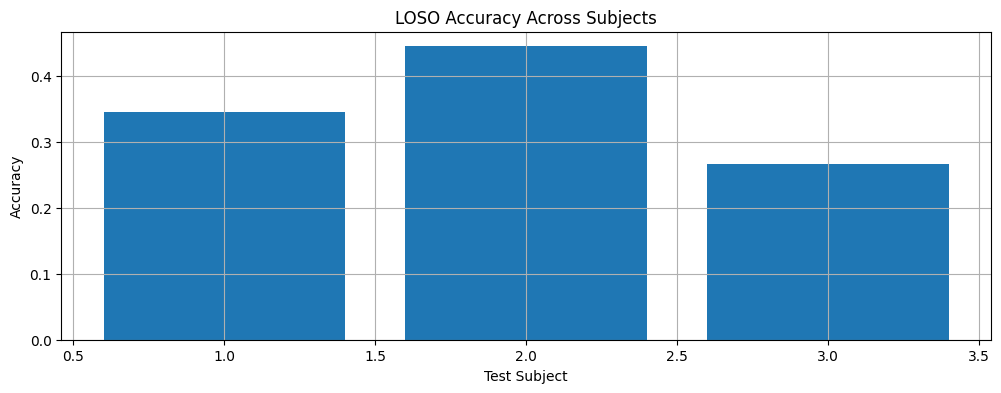

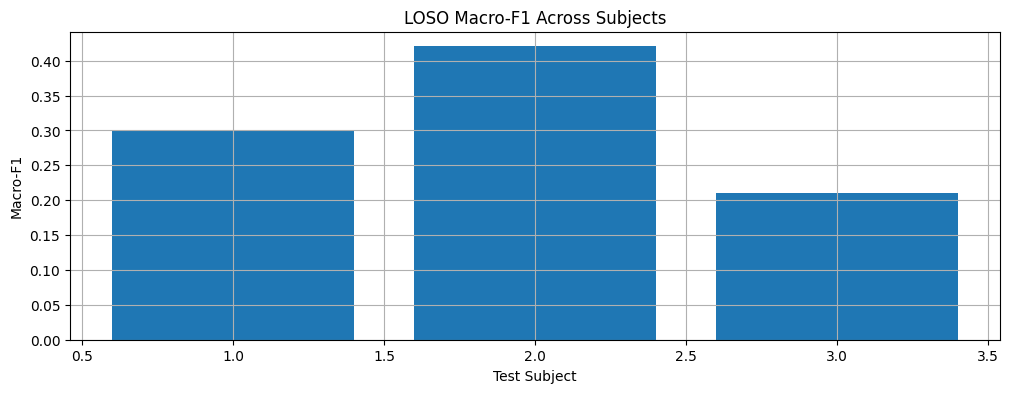

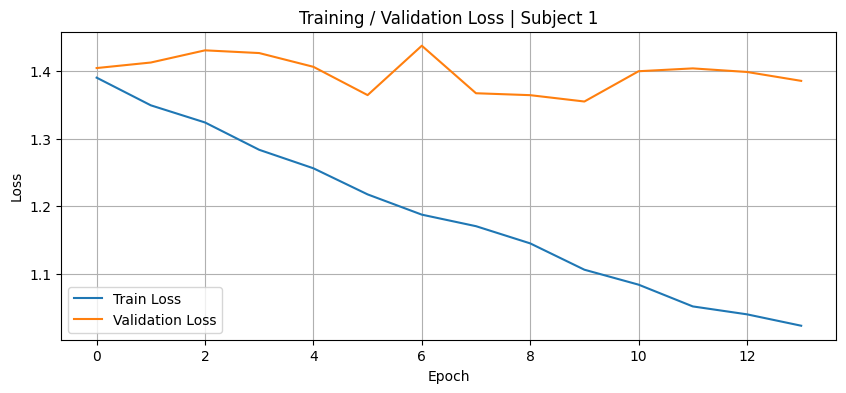


Best subjects:


,fold,test_subject,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,used_time_seconds
1,2,2,0.444444,0.434683,0.420411,1.238306,259.571832
0,1,1,0.344444,0.348591,0.300481,1.420478,205.809303
2,3,3,0.266667,0.279809,0.210786,2.082051,430.526369



Worst subjects:


,fold,test_subject,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,used_time_seconds
2,3,3,0.266667,0.279809,0.210786,2.082051,430.526369
0,1,1,0.344444,0.348591,0.300481,1.420478,205.809303
1,2,2,0.444444,0.434683,0.420411,1.238306,259.571832


In [ ]:
# Cell 5 — Results and visualization

loso_summary = loso_df.drop(
    columns=["confusion_matrix"],
    errors="ignore"
)

print("Number of LOSO folds:")
print(len(loso_summary))

print("\nMean results:")

mean_results = loso_summary[
    [
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_loss",
        "used_time_seconds"
    ]
].mean()

print(mean_results)

print("\nStandard deviation:")

std_results = loso_summary[
    [
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_loss",
        "used_time_seconds"
    ]
].std()

print(std_results)

summary_path = os.path.join(
    cfg.results_dir,
    "loso_summary.csv"
)

loso_summary.to_csv(
    summary_path,
    index=False
)

print("\nSaved summary to:", summary_path)


plt.figure(figsize=(12, 4))
plt.bar(
    loso_summary["test_subject"],
    loso_summary["test_accuracy"]
)
plt.xlabel("Test Subject")
plt.ylabel("Accuracy")
plt.title("LOSO Accuracy Across Subjects")
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 4))
plt.bar(
    loso_summary["test_subject"],
    loso_summary["test_macro_f1"]
)
plt.xlabel("Test Subject")
plt.ylabel("Macro-F1")
plt.title("LOSO Macro-F1 Across Subjects")
plt.grid(True)
plt.show()


first_subject = list(histories.keys())[0]
history = histories[first_subject]

plt.figure(figsize=(10, 4))
plt.plot(
    history["train_loss"],
    label="Train Loss"
)
plt.plot(
    history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training / Validation Loss | Subject {first_subject}")
plt.legend()
plt.grid(True)
plt.show()


print("\nBest subjects:")

display(
    loso_summary.sort_values(
        "test_accuracy",
        ascending=False
    ).head()
)

print("\nWorst subjects:")

display(
    loso_summary.sort_values(
        "test_accuracy",
        ascending=True
    ).head()
)